<a href="https://colab.research.google.com/github/akshita-singh-2808/airlines_churn_prediction_prev/blob/main/01_Data_Cleaning_EDA_leakage_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ✈️ Airline Customer Churn Prediction: A Data-Driven Approach

This notebook presents a comprehensive analysis of airline customer data to identify key factors contributing to churn and develop actionable strategies for retention. It encompasses data cleaning, exploratory data analysis, feature engineering, and churn labeling, culminating in a robust dataset ready for machine learning model development.

##  Business Problem

Customer churn is a critical challenge for airlines, directly impacting revenue and long-term profitability. Retaining existing customers is often more cost-effective than acquiring new ones. This project aims to:

1.  **Identify drivers of churn**: Understand what demographic, behavioral, and loyalty-related factors cause customers to leave.
2.  **Predict churn**: Develop a robust dataset that can be used to build a predictive model to identify customers at high risk of churning.
3.  **Inform retention strategies**: Provide data-driven insights and recommendations for targeted interventions to reduce churn and enhance customer loyalty.

## Setup and Data Loading

This section handles the initial environment setup, including mounting Google Drive for data access and loading the necessary datasets into pandas DataFrames. We are working with four distinct datasets:

*   `Airline Loyalty Data Dictionary.csv`: Provides metadata and descriptions for the other datasets.
*   `Customer Flight Activity.csv`: Contains detailed records of customer flight behavior.
*   `Customer Loyalty History.csv`: Stores historical information about customer loyalty programs.
*   `Calendar.csv`: Likely contains time-based information to support date-related analysis.

In [49]:
"hello world"

'hello world'

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [51]:
from pathlib import Path
import pandas as pd

# Base folder containing the data files
BASE_PATH = Path("/content/drive/MyDrive/airlines_churn_prediction-main/data")


In [52]:


dictionary = pd.read_csv(BASE_PATH / "Airline Loyalty Data Dictionary.csv")
activity  = pd.read_csv(BASE_PATH / "Customer Flight Activity.csv")
loyalty   = pd.read_csv(BASE_PATH / "Customer Loyalty History.csv")
calendar  = pd.read_csv(BASE_PATH / "Calendar.csv")

## Data Cleaning


In [53]:
loyalty

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN


###  Initial Data Inspection

Before cleaning, it's good practice to inspect the data types and identify missing values. This helps us understand the scope of cleaning required.

In [54]:
loyalty.isnull().sum()

,0
Loyalty Number,0
Country,0
Province,0
City,0
Postal Code,0
Gender,0
Education,0
Salary,4238
Marital Status,0
Loyalty Card,0


# STEP 1 : FIX BROKEN SALARIES
The problem — 4,258 records with broken salary

4,238 rows had NaN (blank salary)
20 rows had negative salary (e.g. –$58,486) — impossible, clearly a data entry mistake (someone probably typed without the dollar sign, or it was a system glitch flipping the sign)

In [55]:
import numpy as np
import pandas as pd


In [56]:
loyalty.loc[loyalty['Salary'] < 0, 'Salary'] = np.nan   # negatives → blank


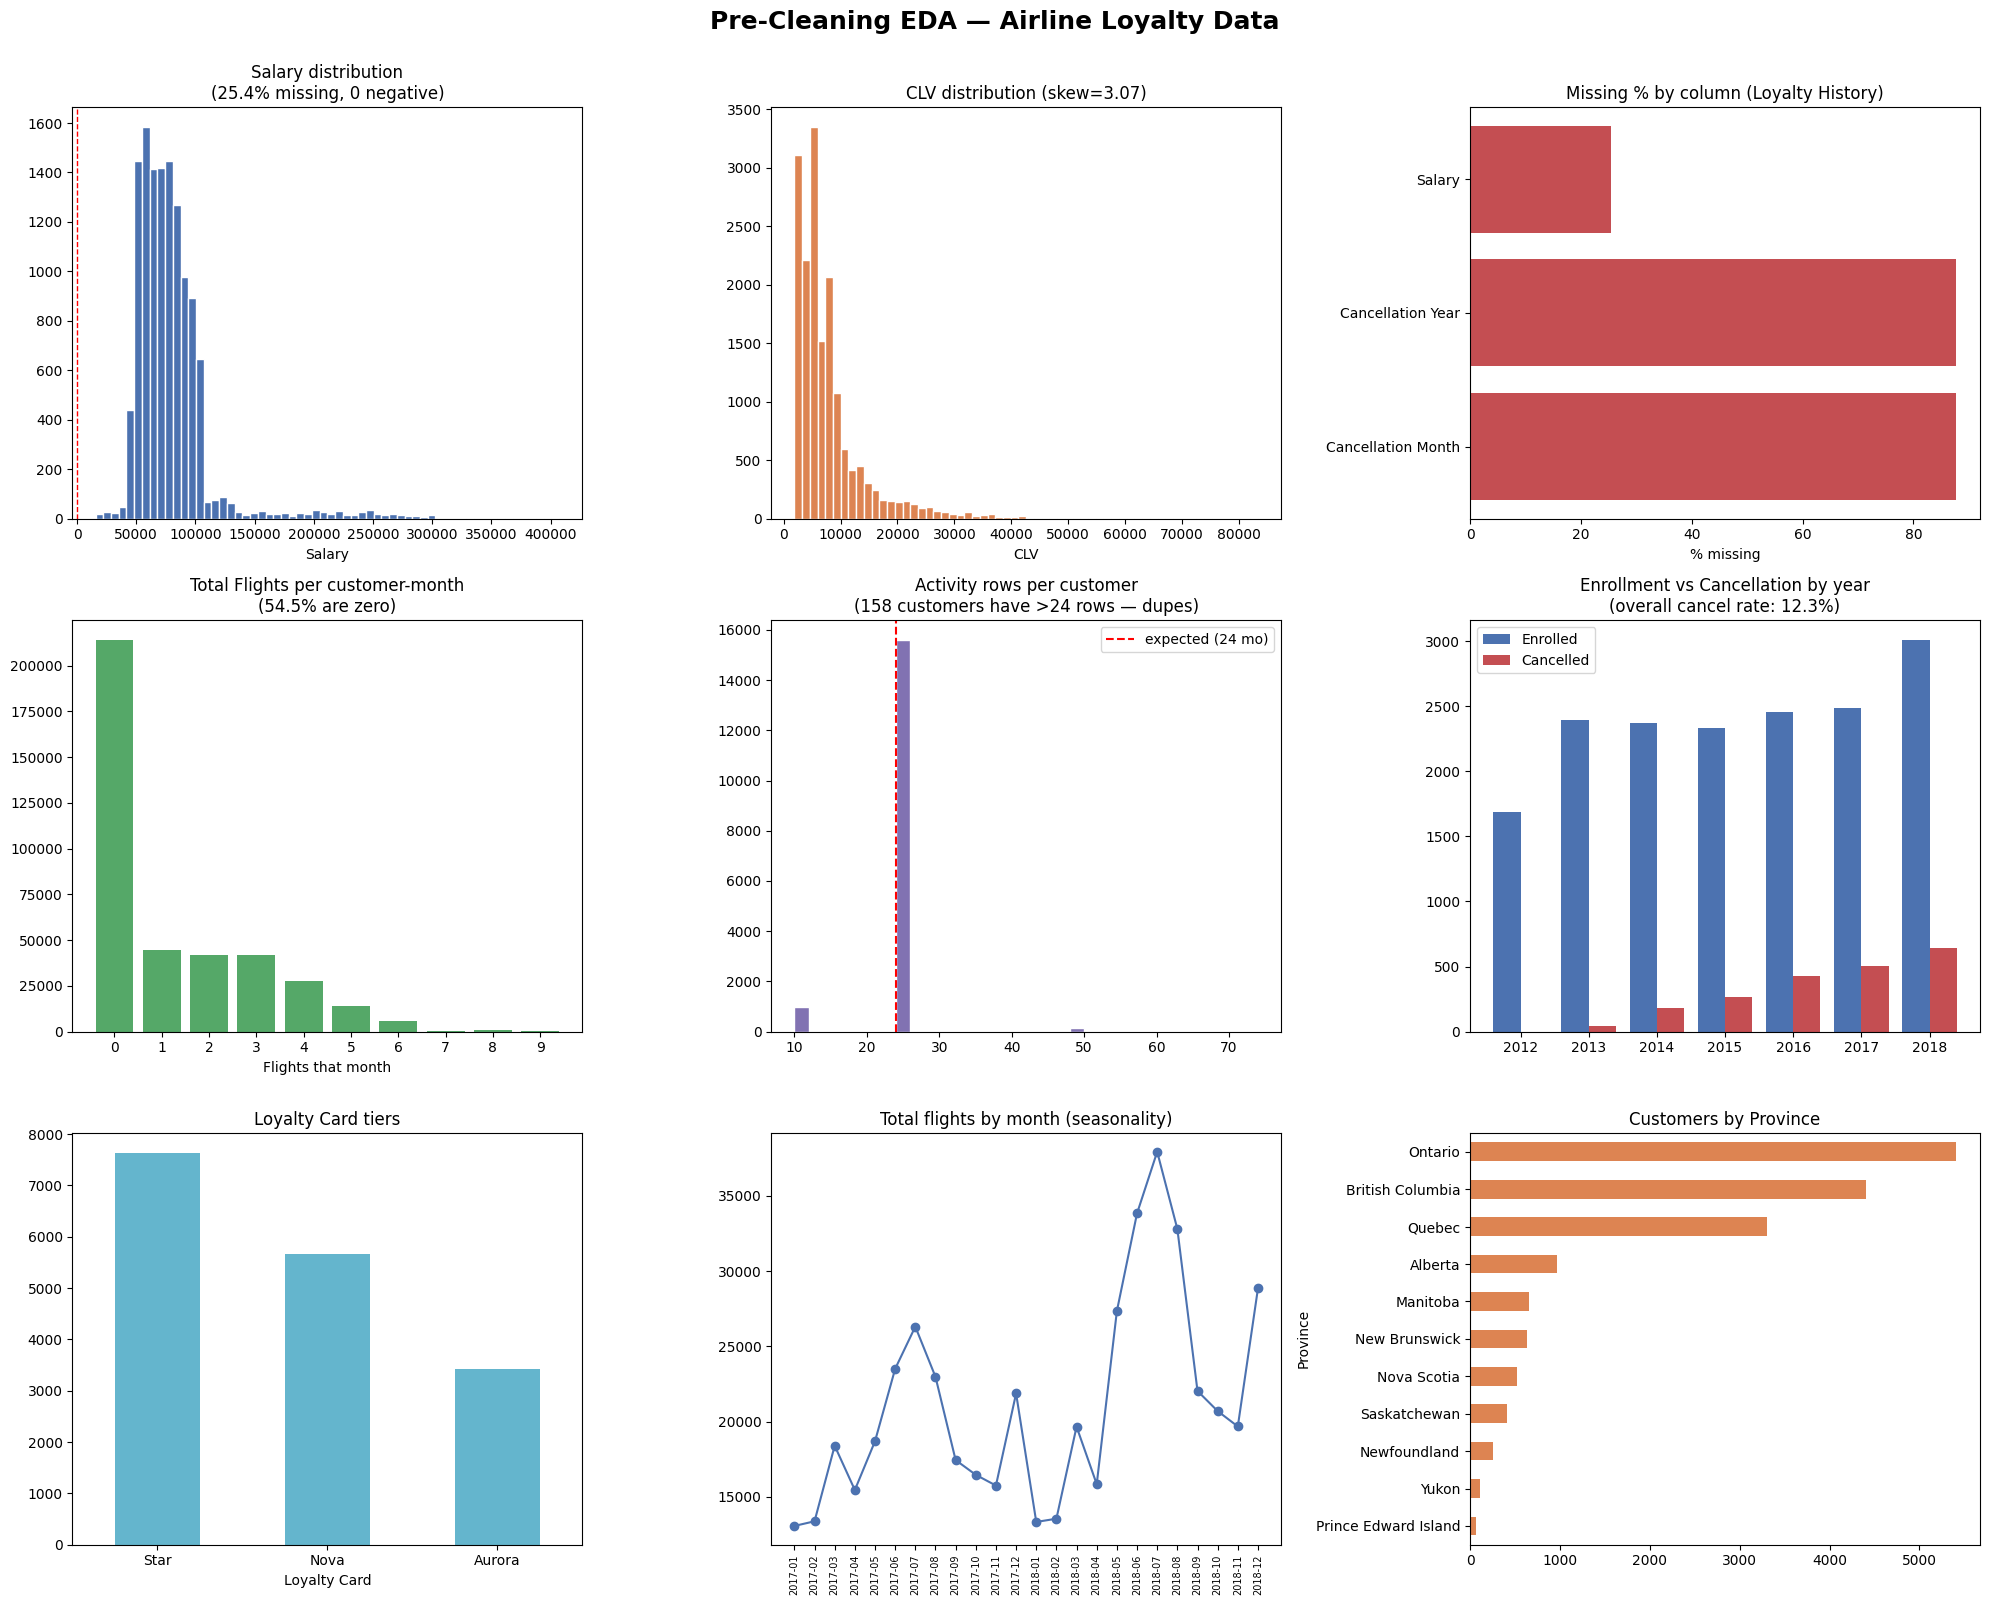

In [57]:


fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle("Pre-Cleaning EDA — Airline Loyalty Data", fontsize=18, fontweight='bold', y=1.00)

# 1. Salary distribution (missingness + negatives + skew)
ax = axes[0, 0]
sal = loyalty['Salary'].dropna()
ax.hist(sal, bins=60, color='#4C72B0', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title(f"Salary distribution\n({loyalty['Salary'].isnull().mean()*100:.1f}% missing, "
             f"{(loyalty['Salary'] < 0).sum()} negative)")
ax.set_xlabel("Salary")

# 2. CLV distribution (skew/outliers)
ax = axes[0, 1]
ax.hist(loyalty['CLV'], bins=60, color='#DD8452', edgecolor='white')
ax.set_title(f"CLV distribution (skew={loyalty['CLV'].skew():.2f})")
ax.set_xlabel("CLV")

# 3. Missingness by column
ax = axes[0, 2]
miss = loyalty.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]
ax.barh(miss.index, miss.values * 100, color='#C44E52')
ax.set_title("Missing % by column (Loyalty History)")
ax.set_xlabel("% missing")

# 4. Total Flights per customer-month (zero inflation)
ax = axes[1, 0]
vc = activity['Total Flights'].value_counts().sort_index().head(10)
ax.bar(vc.index.astype(str), vc.values, color='#55A868')
ax.set_title(f"Total Flights per customer-month\n({(activity['Total Flights']==0).mean()*100:.1f}% are zero)")
ax.set_xlabel("Flights that month")

# 5. Rows per customer (coverage / duplicate check)
ax = axes[1, 1]
counts = activity.groupby('Loyalty Number').size()
ax.hist(counts, bins=range(10, 75, 2), color='#8172B2', edgecolor='white')
ax.axvline(24, color='red', linestyle='--', label='expected (24 mo)')
ax.set_title(f"Activity rows per customer\n({(counts > 24).sum()} customers have >24 rows — dupes)")
ax.legend()

# 6. Enrollment year vs Cancellation year
ax = axes[1, 2]
enroll = loyalty['Enrollment Year'].value_counts().sort_index()
cancel = loyalty['Cancellation Year'].value_counts().sort_index()
ax.bar(enroll.index - 0.2, enroll.values, width=0.4, label='Enrolled', color='#4C72B0')
ax.bar(cancel.index + 0.2, cancel.values, width=0.4, label='Cancelled', color='#C44E52')
ax.set_title(f"Enrollment vs Cancellation by year\n"
             f"(overall cancel rate: {loyalty['Cancellation Year'].notna().mean()*100:.1f}%)")
ax.legend()

# 7. Loyalty Card tier distribution
ax = axes[2, 0]
loyalty['Loyalty Card'].value_counts().plot(kind='bar', ax=ax, color='#64B5CD')
ax.set_title("Loyalty Card tiers")
ax.tick_params(axis='x', rotation=0)

# 8. Monthly flight volume over time (seasonality)
ax = axes[2, 1]
monthly = activity.groupby(['Year', 'Month'])['Total Flights'].sum().reset_index()
monthly['ym'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
monthly = monthly.sort_values(['Year', 'Month'])
ax.plot(monthly['ym'], monthly['Total Flights'], marker='o', color='#4C72B0')
ax.set_title("Total flights by month (seasonality)")
ax.tick_params(axis='x', rotation=90, labelsize=7)

# 9. Province distribution
ax = axes[2, 2]
loyalty['Province'].value_counts().plot(kind='barh', ax=ax, color='#DD8452')
ax.set_title("Customers by Province")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("pre_cleaning_eda_dashboard.png", dpi=130, bbox_inches='tight')
plt.show()

#### Marking Imputed Salaries

We create a boolean flag, `Salary_Was_Imputed`, to indicate records where the original salary was either missing or invalid. This can be a useful feature for our model, as imputed values might carry different predictive weight.

In [58]:
loyalty['Salary_Was_Imputed'] = loyalty['Salary'].isnull()    #if the salary is null it will show true else false

In [59]:
loyalty


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Salary_Was_Imputed
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,False
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,True
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,True
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN,True
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN,True
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN,False
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN,True
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,NaN,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN,True


#### Imputing Missing Salaries

* To fill the `NaN` values, we use a more sophisticated imputation strategy. Salaries are imputed based on the median salary of customers with the same `Education` level and `Loyalty Card` type.

* This approach assumes that salary distributions vary by education and loyalty tier, making the imputation more accurate than a simple overall median.

In [60]:
loyalty['Salary_Imputed'] = loyalty.groupby(     #calculate the median salary using loyalty card and education as group
    ['Education', 'Loyalty Card']
)['Salary'].transform(
    lambda x: x.fillna(x.median())
)


#### Handling Remaining Missing Salaries

In cases where a specific `Education` and `Loyalty Card` combination might still result in `NaN` (e.g., if an entire group has missing salaries), we apply a fallback: fill any remaining `NaN` values with the overall median salary from the original, non-negative `Salary` column. This ensures all `Salary_Imputed` values are complete.

In [61]:
loyalty['Salary_Imputed'] = loyalty['Salary_Imputed'].fillna(
    loyalty['Salary'].median()
)

In [62]:
loyalty['Salary_Imputed'].isnull().sum()

np.int64(0)

In [63]:
loyalty["enrollment_index"] = (
    loyalty["Enrollment Year"] * 12 + loyalty["Enrollment Month"]
)

loyalty["cancellation_index"] = (
    loyalty["Cancellation Year"] * 12 + loyalty["Cancellation Month"]
)

In [64]:
invalid=loyalty[loyalty["cancellation_index"]<=loyalty["enrollment_index"]]

In [65]:
len(invalid)

11

 #  Step 2: Removing Ambiguous Cancellation Records
 DROP 11 BAD CANCELLATION RECORDS

* 11 customer records were identified where the cancellation month was the same as or earlier than the enrollment month. Since the dataset only contains month-level granularity (not exact dates), these records are considered ambiguous for churn labeling.
*  For example, a customer could realistically enroll on 10-Dec-2017 and cancel on 25-Dec-2017, which would still appear as the same month in the dataset. However, because exact dates are unavailable, it is impossible to distinguish valid same-month cancellations from logically inconsistent cases. To maintain cleaner and more reliable churn labels for modeling, these 11 records were excluded from the training dataset.

In [66]:
loyalty['enroll_ym'] = loyalty['Enrollment Year'] * 100 + loyalty['Enrollment Month']  #this is done so that dates can be comparable

In [67]:
cancelled = loyalty[loyalty['Cancellation Year'].notna()].copy()  #this keeps only cancelled customers

In [68]:
cancelled['cancel_ym'] = cancelled['Cancellation Year'] * 100 + cancelled['Cancellation Month']

In [69]:
cancelled['is_bad'] = cancelled['cancel_ym'] <= cancelled['enroll_ym']  #impossible conditions - when the cancellation is done before enrollment


In [70]:
print(cancelled[cancelled['is_bad']][['Loyalty Number','Enrollment Year',
      'Enrollment Month','Cancellation Year','Cancellation Month']])


       Loyalty Number  Enrollment Year  Enrollment Month  Cancellation Year  \
1461           607266             2016                 3             2016.0   
1756           939593             2013                 9             2013.0   
1957           140042             2014                 8             2014.0   
3145           488724             2013                 1             2013.0   
3157           160779             2017                12             2017.0   
5732           472283             2014                 4             2014.0   
5804           239221             2014                 5             2014.0   
8860           896685             2016                12             2016.0   
10755          304528             2018                 8             2018.0   
12147          871455             2017                 6             2017.0   
13498          110603             2017                10             2017.0   

       Cancellation Month  
1461                  3

#### Final Cleaning: Removing Bad Records

Finally, the identified 'bad' cancellation records are removed from the `loyalty` DataFrame to create `loyalty_clean`. This ensures our churn analysis is based on a logically consistent dataset.

In [71]:
loyalty_clean = loyalty[
    ~loyalty['Loyalty Number'].isin(
        cancelled.loc[cancelled['is_bad'], 'Loyalty Number']
    )
].copy()

In [72]:
loyalty_clean

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,...,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Salary_Was_Imputed,Salary_Imputed,enrollment_index,cancellation_index,enroll_ym
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,...,Standard,2016,2,NaN,NaN,False,83236.0,24194,NaN,201602
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,...,Standard,2016,3,NaN,NaN,True,73510.0,24195,NaN,201603
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,...,Standard,2014,7,2018.0,1.0,True,73510.0,24175,24217.0,201407
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,...,Standard,2013,2,NaN,NaN,True,73510.0,24158,NaN,201302
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,...,Standard,2014,10,NaN,NaN,False,103495.0,24178,NaN,201410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,...,Standard,2012,12,NaN,NaN,True,73510.0,24156,NaN,201212
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,...,Standard,2014,9,NaN,NaN,False,89210.0,24177,NaN,201409
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,...,Standard,2014,3,NaN,NaN,True,73510.0,24171,NaN,201403
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,NaN,Married,Star,...,2018 Promotion,2018,4,NaN,NaN,True,71412.0,24220,NaN,201804


In [73]:

loyalty_clean.drop(columns=["enrollment_index","cancellation_index"], inplace=True)

In [74]:
loyalty_clean

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Salary_Was_Imputed,Salary_Imputed,enroll_ym
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,False,83236.0,201602
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,True,73510.0,201603
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,True,73510.0,201407
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN,True,73510.0,201302
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,False,103495.0,201410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN,True,73510.0,201212
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN,False,89210.0,201409
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN,True,73510.0,201403
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,NaN,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN,True,71412.0,201804


### Step 3 (REVISED): Time-Aware Churn Label — Feature Window vs. Outcome Window

#this prevents data leakage

**Why this changed:** the original approach computed behavioral features (`Total_Flights`, `Avg_Flights_Month`, `Flights_2018`, etc.) over the *entire* dataset span (Jan 2017–Dec 2018), and then defined churn using `Months_Since_Last_Flight` measured over that *same* span. That means the features and the label were built from overlapping time windows — a customer who "never flew" trivially has `Total_Flights = 0`, which isn't a predictive signal, it's just the label restated.

To fix this, we split the timeline into two non-overlapping pieces:
- **Feature window**: Jan 2017 – Dec 2017 (`CUTOFF_YM = 201712`). All behavioral features are computed using *only* this data — this is what we'd actually know about a customer at prediction time.
- **Outcome window**: Jan 2018 – Dec 2018 (`OUTCOME_END_YM = 201812`). Churn is defined using what happens *after* the cutoff — this is what we're trying to predict.

We also restrict the modeling population to customers who were enrolled and still active as of the cutoff — you can't "predict" future churn for someone who had already left before the observation window even started.

In [75]:
def ym_to_months(ym):
    year = ym // 100
    month = ym % 100
    return year * 12 + month

CUTOFF_YM = 201712        # end of feature window (what we "know" at prediction time)
OUTCOME_END_YM = 201812   # end of outcome window (what we're predicting into)

cutoff_months = ym_to_months(CUTOFF_YM)
outcome_end_months = ym_to_months(OUTCOME_END_YM)

loyalty_clean['enroll_ym'] = loyalty_clean['Enrollment Year'] * 100 + loyalty_clean['Enrollment Month']
loyalty_clean['cancel_ym'] = loyalty_clean['Cancellation Year'] * 100 + loyalty_clean['Cancellation Month']
activity['activity_ym'] = activity['Year'] * 100 + activity['Month']

In [76]:
loyalty_clean

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Salary_Was_Imputed,Salary_Imputed,enroll_ym,cancel_ym
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,False,83236.0,201602,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,True,73510.0,201603,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,True,73510.0,201407,201801.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN,True,73510.0,201302,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,False,103495.0,201410,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN,True,73510.0,201212,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN,False,89210.0,201409,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN,True,73510.0,201403,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,NaN,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN,True,71412.0,201804,NaN


In [77]:
activity

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,activity_ym
0,100590,2018,6,12,15276,22914.0,0,0,201806
1,100590,2018,7,12,9168,13752.0,0,0,201807
2,100590,2018,5,4,6504,9756.0,0,0,201805
3,100590,2018,10,0,0,0.0,512,92,201810
4,100590,2018,2,0,0,0.0,0,0,201802
...,...,...,...,...,...,...,...,...,...
392931,999986,2018,4,0,0,0.0,0,0,201804
392932,999986,2018,5,0,0,0.0,0,0,201805
392933,999986,2018,6,0,0,0.0,0,0,201806
392934,999986,2018,9,0,0,0.0,0,0,201809


#### Defining the Modeling Population

We only keep customers who:
1. Enrolled on or before the cutoff (so they have a full feature history), and
2. Had not already cancelled on or before the cutoff (so they're still "in play" at prediction time).

In [78]:
population = loyalty_clean[
    (loyalty_clean['enroll_ym'] <= CUTOFF_YM) &
    ~((loyalty_clean['cancel_ym'].notna()) & (loyalty_clean['cancel_ym'] <= CUTOFF_YM))
].copy()

print(f"Customers enrolled after cutoff or cancelled before cutoff (excluded): {len(loyalty_clean) - len(population)}")
print(f"Remaining modeling population: {len(population)}")

Customers enrolled after cutoff or cancelled before cutoff (excluded): 4421
Remaining modeling population: 12305


#### Splitting Activity Into Feature Window and Outcome Window

In [79]:
feat_activity = activity[activity['activity_ym'] <= CUTOFF_YM] # these become features and model is used to see only these
outcome_activity = activity[(activity['activity_ym'] > CUTOFF_YM) &
    (activity['activity_ym'] <= OUTCOME_END_YM)] #this is used to measure whether the customer churned

print(f"Feature window rows: {len(feat_activity)}  (<= {CUTOFF_YM})")
print(f"Outcome window rows: {len(outcome_activity)}  ({CUTOFF_YM} < ym <= {OUTCOME_END_YM})")

Feature window rows: 191100  (<= 201712)
Outcome window rows: 201836  (201712 < ym <= 201812)


#### Recency-at-Cutoff: A Legitimate (Non-Leaky) Feature

`Months_Since_Last_Flight_at_cutoff` only uses feature-window data — it answers "how recently had this customer flown, as of the point we're making the prediction?" That's a valid predictive feature, unlike the original `Months_Since_Last_Flight` which was measured against the *end of the outcome window* and therefore encoded the label itself.

We also use this to drop customers who were already behaviorally dead (6+ months inactive) *before* the observation window even starts — they can't meaningfully be "predicted" to churn since they've effectively already churned.

In [80]:
last_active_at_cutoff = (
    feat_activity[feat_activity['Total Flights'] > 0]
    .groupby('Loyalty Number')['activity_ym'].max()
)
population['Last_Active_YM_at_cutoff'] = population['Loyalty Number'].map(last_active_at_cutoff)
population['Months_Since_Last_Flight_at_cutoff'] = cutoff_months - population['Last_Active_YM_at_cutoff'].apply(
    lambda x: ym_to_months(x) if pd.notna(x) else np.nan
)

already_dead_at_cutoff = population['Months_Since_Last_Flight_at_cutoff'] >= 6
print(f"Already behaviorally dead before cutoff (excluded): {already_dead_at_cutoff.fillna(False).sum()}")
population = population[~already_dead_at_cutoff.fillna(False)]

Already behaviorally dead before cutoff (excluded): 54


In [81]:
population

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,...,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Salary_Was_Imputed,Salary_Imputed,enroll_ym,cancel_ym,Last_Active_YM_at_cutoff,Months_Since_Last_Flight_at_cutoff
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,...,2016,2,NaN,NaN,False,83236.0,201602,NaN,201712.0,0.0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,...,2016,3,NaN,NaN,True,73510.0,201603,NaN,201711.0,1.0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,...,2014,7,2018.0,1.0,True,73510.0,201407,201801.0,201711.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,...,2013,2,NaN,NaN,True,73510.0,201302,NaN,201712.0,0.0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,...,2014,10,NaN,NaN,False,103495.0,201410,NaN,201711.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16729,302460,Canada,British Columbia,Whistler,V6T 1Y8,Female,Bachelor,88425.0,Married,Star,...,2014,9,NaN,NaN,False,88425.0,201409,NaN,201710.0,2.0
16731,900501,Canada,Ontario,Sudbury,M5V 1G5,Male,College,NaN,Single,Star,...,2012,9,NaN,NaN,True,73510.0,201209,NaN,201712.0,0.0
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,...,2012,12,NaN,NaN,True,73510.0,201212,NaN,201712.0,0.0
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,...,2014,9,NaN,NaN,False,89210.0,201409,NaN,201711.0,1.0


#### Building the Churn Label From the Outcome Window Only

This is the one place we deliberately use data *through* the end of the outcome window — that's expected, since the label has to be observed over the full period we're predicting into. The key discipline is that this data is used **only** to build `Churn`, never as a feature.

In [82]:
last_active_full = activity[activity['Total Flights'] > 0].groupby('Loyalty Number')['activity_ym'].max()
population['Last_Active_YM_full'] = population['Loyalty Number'].map(last_active_full)
population['Months_Since_Last_Flight_outcome'] = outcome_end_months - population['Last_Active_YM_full'].apply(
    lambda x: ym_to_months(x) if pd.notna(x) else np.nan
)

# Formal churn: cancellation happens strictly inside the outcome window
population['Formal_Churn'] = (
    (population['cancel_ym'] > CUTOFF_YM) & (population['cancel_ym'] <= OUTCOME_END_YM)
).astype(int)

# Behavioral churn: 6+ months inactive as measured at the END of the outcome window
population['Behavioral_Churn'] = (population['Months_Since_Last_Flight_outcome'] >= 6).astype(int)

# Never flew at all, in either window
population['Never_Flew'] = population['Last_Active_YM_full'].isnull().astype(int)

population['Churn'] = (
    (population['Formal_Churn'] == 1) |
    (population['Behavioral_Churn'] == 1) |
    (population['Never_Flew'] == 1)
).astype(int)

print("Churn breakdown:")
print(f"  Formal churn     : {population['Formal_Churn'].sum()}")
print(f"  Behavioral churn : {population['Behavioral_Churn'].sum()}")
print(f"  Never flew       : {population['Never_Flew'].sum()}")
print(f"  Total churned    : {population['Churn'].sum()} ({population['Churn'].mean()*100:.1f}%)")

Churn breakdown:
  Formal churn     : 486
  Behavioral churn : 379
  Never flew       : 242
  Total churned    : 803 (6.6%)


# Feature Engineering (REVISED — feature window only)

Every aggregate below is computed from `feat_activity` (Jan–Dec 2017 only). None of it touches the outcome window, so nothing here can leak the label.

In [83]:
agg = feat_activity.groupby('Loyalty Number').agg(
    Total_Flights        = ('Total Flights', 'sum'),
    Total_Distance       = ('Distance', 'sum'),
    Total_Points_Acc     = ('Points Accumulated', 'sum'),
    Total_Points_Red     = ('Points Redeemed', 'sum'),
    Total_Dollar_Red     = ('Dollar Cost Points Redeemed', 'sum'),
    Avg_Flights_Month    = ('Total Flights', 'mean'),
    Max_Flights_Month    = ('Total Flights', 'max'),
    Active_Months        = ('Total Flights', lambda x: (x > 0).sum()),
    Total_Months         = ('Total Flights', 'count'),
).reset_index()

agg["Redemption_Ratio"] = agg["Total_Points_Red"] / (agg["Total_Points_Acc"] + 0.0001)
agg["Activity_Rate"] = agg["Active_Months"] / (agg["Total_Flights"] + 0.0001)
agg["Avg_Distance_Per_Flight"] = agg["Total_Distance"] / (agg["Total_Flights"] + 0.0001)
agg['Quarter'] = pd.cut(feat_activity['Month'], bins=[0,3,6,9,12], labels=['Q1','Q2','Q3','Q4'])

In [84]:
# Seasonal flights within the FEATURE WINDOW only
seasonal = feat_activity.merge(agg[['Loyalty Number']], on='Loyalty Number')
seasonal['Quarter'] = pd.cut(seasonal['Month'], bins=[0,3,6,9,12], labels=['Q1','Q2','Q3','Q4'])
seasonal = seasonal[seasonal['Total Flights'] > 0].groupby(
    ['Loyalty Number','Quarter']
)['Total Flights'].sum().unstack(fill_value=0).reset_index()
seasonal.columns = ['Loyalty Number','Flights_Q1','Flights_Q2','Flights_Q3','Flights_Q4']

agg = pd.merge(agg, seasonal, on='Loyalty Number', how='left')

/tmp/ipykernel_12215/2640563598.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal = seasonal[seasonal['Total Flights'] > 0].groupby(


In [85]:
seasonal

,Loyalty Number,Flights_Q1,Flights_Q2,Flights_Q3,Flights_Q4
0,100018,5,2,9,8
1,100102,8,3,7,7
2,100140,3,5,7,7
3,100214,2,0,2,6
4,100272,5,9,2,4
...,...,...,...,...,...
12434,999631,3,8,14,6
12435,999731,5,1,6,3
12436,999788,1,5,5,1
12437,999902,3,7,10,7


In [86]:
agg

,Loyalty Number,Total_Flights,Total_Distance,Total_Points_Acc,Total_Points_Red,Total_Dollar_Red,Avg_Flights_Month,Max_Flights_Month,Active_Months,Total_Months,Redemption_Ratio,Activity_Rate,Avg_Distance_Per_Flight,Quarter,Flights_Q1,Flights_Q2,Flights_Q3,Flights_Q4
0,100018,24,37760,37760.0,1128,203,2.000000,4,10,12,2.987288e-02,0.416665,1573.326778,NaN,5.0,2.0,9.0,8.0
1,100102,25,39884,39884.0,1195,215,2.083333,5,8,12,2.996189e-02,0.319999,1595.353619,NaN,8.0,3.0,7.0,7.0
2,100140,22,31582,31582.0,0,0,1.833333,5,9,12,0.000000e+00,0.409089,1435.538929,NaN,3.0,5.0,7.0,7.0
3,100214,10,18186,18186.0,861,155,0.833333,3,4,12,4.734411e-02,0.399996,1818.581814,NaN,2.0,0.0,2.0,6.0
4,100272,20,28486,28486.0,393,71,1.666667,5,6,12,1.379625e-02,0.299999,1424.292879,NaN,5.0,9.0,2.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15761,999891,0,0,0.0,414,75,0.000000,0,0,12,4.140000e+06,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
15762,999902,27,43123,43123.0,492,89,2.250000,5,10,12,1.140922e-02,0.370369,1597.142233,NaN,3.0,7.0,10.0,7.0
15763,999911,0,0,0.0,0,0,0.000000,0,0,12,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
15764,999940,7,11231,11231.0,0,0,0.583333,5,2,12,0.000000e+00,0.285710,1604.405651,NaN,0.0,0.0,0.0,7.0




```

--- Seasonal breakdown (within feature window) ---
TAG each feat_activity row with Quarter (Q1–Q4, based on Month)
seasonal = GROUP BY (Loyalty Number, Quarter), SUM(Total Flights) WHERE Total Flights > 0
PIVOT to columns: Flights_Q1, Flights_Q2, Flights_Q3, Flights_Q4
MERGE seasonal into agg

```






**Note on `Flights_Trend`**: this used to compare 2017 vs 2018 flight totals — but 2018 is entirely inside the outcome window now, so that comparison is no longer available as a *feature* (using it would be exactly the leakage we're trying to remove). If you want a trend feature, compute it **within** the feature window instead, e.g. first-half-2017 vs second-half-2017 flight counts.

In [87]:
# Trend feature computed entirely within the feature window (H1 2017 vs H2 2017)
h1 = feat_activity[feat_activity['Month'] <= 6].groupby('Loyalty Number')['Total Flights'].sum()
h2 = feat_activity[feat_activity['Month'] > 6].groupby('Loyalty Number')['Total Flights'].sum()
agg['Flights_H1'] = agg['Loyalty Number'].map(h1).fillna(0)
agg['Flights_H2'] = agg['Loyalty Number'].map(h2).fillna(0)
agg['Flights_Trend'] = agg['Flights_H2'] - agg['Flights_H1']  # positive = accelerating within 2017, negative = slowing down

In [88]:
population["Tenure"] = (CUTOFF_YM // 100) - population["Enrollment Year"]



```
--- Trend feature (H1 2017 vs H2 2017, NOT 2017 vs 2018) ---
Flights_H1 = SUM(Total Flights) WHERE Month <= 6   (within feature window)
Flights_H2 = SUM(Total Flights) WHERE Month > 6     (within feature window)
Flights_Trend = Flights_H2 - Flights_H1

Tenure = (CUTOFF_YM's year) - Enrollment_Year


```



#### Encoding Categorical Variables (unchanged from original — no leakage here)

In [89]:
population["Male_Enc"] = pd.get_dummies(population['Gender'], drop_first=True).astype(int)

population['Marital_Enc'] = population['Marital Status'].map({'Single':0,'Married':1,'Divorced':2})

population['Education_Enc'] = population['Education'].map({
    'High School or Below':0, 'College':1, 'Bachelor':2, 'Master':3, 'Doctor':4
})

population["Card_Enc"] = population["Loyalty Card"].map({'Star':0, 'Nova':1, 'Aurora':2})

population['Promo_Enroll'] = (population['Enrollment Type'] == '2018 Promotion').astype(int)

```
============================================================
ENCODE CATEGORICAL VARIABLES (unchanged, not leaky)
============================================================
Male_Enc     = one-hot(Gender, drop_first)
Marital_Enc  = map {Single:0, Married:1, Divorced:2}
Education_Enc= map {High School or Below:0, College:1, Bachelor:2, Master:3, Doctor:4}
Card_Enc     = map {Star:0, Nova:1, Aurora:2}
Promo_Enroll = 1 IF Enrollment Type == '2018 Promotion' ELSE 0

```



In [90]:
model_df = pd.merge(population, agg, on='Loyalty Number', how='left')

model_df.fillna({
    'Total_Flights': 0, 'Total_Distance': 0, 'Total_Points_Acc': 0, 'Total_Points_Red': 0,
    'Active_Months': 0, 'Activity_Rate': 0, 'Redemption_Ratio': 0, 'Flights_Trend': 0,
    'Flights_Q1': 0, 'Flights_Q2': 0, 'Flights_Q3': 0, 'Flights_Q4': 0,
    'Months_Since_Last_Flight_at_cutoff': 999  # customer had literally no flights in the feature window
}, inplace=True)

#### Final Feature List

Note what's **removed** compared to the original: `Months_Since_Last_Flight` (outcome-window version — leaky), `Flights_2017`/`Flights_2018` (2018 is outcome-window — leaky), and `Formal_Churn`/`Behavioral_Churn`/`Never_Flew` are kept only as label-diagnostic columns, clearly separated from the feature block so they can't accidentally get pulled into `X`.

In [91]:
FEATURE_COLS = [
    'Loyalty Number',
    # Demographics
    'Male_Enc', 'Education_Enc', 'Marital_Enc', 'Card_Enc',
    'Salary_Imputed', 'Salary_Was_Imputed', 'CLV', 'Tenure', 'Promo_Enroll',
    # Behavioral (feature-window only)
    'Total_Flights', 'Total_Distance', 'Total_Points_Acc', 'Total_Points_Red',
    'Avg_Flights_Month', 'Max_Flights_Month', 'Active_Months', 'Activity_Rate',
    'Redemption_Ratio', 'Avg_Distance_Per_Flight', 'Months_Since_Last_Flight_at_cutoff',
    # Seasonal (feature-window only)
    'Flights_Q1', 'Flights_Q2', 'Flights_Q3', 'Flights_Q4',
    # Trend (feature-window only, H1 vs H2 2017)
    'Flights_H1', 'Flights_H2', 'Flights_Trend',
]

LABEL_COLS = ['Churn', 'Formal_Churn', 'Behavioral_Churn', 'Never_Flew']

model_df = model_df[FEATURE_COLS + LABEL_COLS]

print(f"Final modeling dataset shape: {model_df.shape}")
print(f"Feature columns: {len(FEATURE_COLS) - 1} (excluding ID)")
print(f"\nNull check:\n{model_df.isnull().sum()[model_df.isnull().sum() > 0]}")

Final modeling dataset shape: (12251, 32)
Feature columns: 27 (excluding ID)

Null check:
Series([], dtype: int64)


In [92]:

model_df


,Loyalty Number,Male_Enc,Education_Enc,Marital_Enc,Card_Enc,Salary_Imputed,Salary_Was_Imputed,CLV,Tenure,Promo_Enroll,...,Flights_Q2,Flights_Q3,Flights_Q4,Flights_H1,Flights_H2,Flights_Trend,Churn,Formal_Churn,Behavioral_Churn,Never_Flew
0,480934,0,2,1,0,83236.0,False,3839.14,1,0,...,8.0,6.0,3.0,9,9,0,0,0,0,0
1,549612,1,1,2,0,73510.0,True,3839.61,1,0,...,5.0,9.0,7.0,15,16,1,0,0,0,0
2,429460,1,1,0,0,73510.0,True,3839.75,3,0,...,4.0,5.0,2.0,9,7,-2,1,1,1,0
3,608370,1,1,0,0,73510.0,True,3839.75,4,0,...,10.0,3.0,3.0,18,6,-12,0,0,0,0
4,530508,1,2,1,0,103495.0,False,3842.79,3,0,...,2.0,4.0,2.0,5,6,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12246,302460,0,2,1,0,88425.0,False,56675.94,3,0,...,3.0,8.0,3.0,5,11,6,0,0,0,0
12247,900501,1,1,0,0,73510.0,True,61134.68,5,0,...,5.0,8.0,2.0,8,10,2,0,0,0,0
12248,823768,0,1,1,0,73510.0,True,61850.19,5,0,...,3.0,6.0,3.0,6,9,3,0,0,0,0
12249,680886,0,2,1,0,89210.0,False,67907.27,3,0,...,5.0,9.0,3.0,11,12,1,0,0,0,0


In [93]:
model_df.to_csv("Modeling_Dataset.csv", index=False)
print("Saved as Modeling_Dataset.csv")
print("\nWhen training: X = model_df[FEATURE_COLS].drop(columns=['Loyalty Number']); y = model_df['Churn']")
print("Never include Formal_Churn / Behavioral_Churn / Never_Flew in X — they are label components, not predictors.")

Saved as Modeling_Dataset.csv

When training: X = model_df[FEATURE_COLS].drop(columns=['Loyalty Number']); y = model_df['Churn']
Never include Formal_Churn / Behavioral_Churn / Never_Flew in X — they are label components, not predictors.




```
============================================================
FINAL ASSEMBLY
============================================================
model_df = MERGE(population, agg, on='Loyalty Number', how='left')

FILL missing values:
    Total_Flights, Total_Distance, Total_Points_Acc, Total_Points_Red,
    Active_Months, Activity_Rate, Redemption_Ratio, Flights_Trend,
    Flights_Q1..Q4                         -> 0   (customer had zero feature-window activity)
    Months_Since_Last_Flight_at_cutoff     -> 999 (never flew in feature window = "very stale")

FEATURE_COLS = [ID + demographics + behavioral(feature-window) + seasonal + trend]
LABEL_COLS   = [Churn, Formal_Churn, Behavioral_Churn, Never_Flew]
                # label components kept SEPARATE from FEATURE_COLS so they never
                # accidentally leak into X during training

model_df = model_df[FEATURE_COLS + LABEL_COLS]

PRINT final shape, feature count, remaining nulls

SAVE model_df -> "Modeling_Dataset.csv"
PRINT reminder: X = model_df[FEATURE_COLS] minus ID
                y = model_df['Churn']
                NEVER put Formal_Churn/Behavioral_Churn/Never_Flew into X
```





```
============================================================
SETUP
============================================================
LOAD libraries: numpy, pandas
LOAD datasets:
    dictionary = Airline Loyalty Data Dictionary.csv
    activity   = Customer Flight Activity.csv
    loyalty    = Customer Loyalty History.csv
    calendar   = Calendar.csv


============================================================
STEP 1: FIX BROKEN SALARIES
============================================================
FOR rows where Salary < 0:
    SET Salary = NaN                      # negative salary is a data entry error

CREATE Salary_Was_Imputed = TRUE if Salary is NaN, else FALSE
                                           # flag so model can learn imputed vs real

# Impute using group median (Education + Loyalty Card)
Salary_Imputed = groupby(Education, Loyalty Card).Salary.fillna(group_median)

# Fallback: if a whole group had no salary data, use global median
Salary_Imputed = Salary_Imputed.fillna(overall_median_of_original_Salary)


============================================================
STEP 2: REMOVE AMBIGUOUS CANCELLATION RECORDS
============================================================
enroll_ym = Enrollment_Year * 100 + Enrollment_Month     # e.g. 2017-05 -> 201705
cancelled = loyalty WHERE Cancellation Year IS NOT NULL
cancel_ym = Cancellation_Year * 100 + Cancellation_Month

is_bad = (cancel_ym <= enroll_ym)          # cancelled same month or before enrolling = impossible

PRINT bad records for inspection

loyalty_clean = loyalty EXCLUDING customers flagged as is_bad   # ~11 rows dropped


============================================================
STEP 3 (REVISED): TIME-AWARE CHURN LABEL
============================================================
DEFINE ym_to_months(ym): convert YYYYMM -> absolute month count (for arithmetic)

CUTOFF_YM       = 201712      # end of FEATURE window (Jan–Dec 2017)
OUTCOME_END_YM  = 201812      # end of OUTCOME window (Jan–Dec 2018)

ADD enroll_ym, cancel_ym to loyalty_clean
ADD activity_ym to activity

--- 3a. Define modeling population ---
KEEP only customers who:
    enrolled on/before CUTOFF_YM               (have full feature history)
    AND NOT already cancelled on/before CUTOFF_YM   (still "alive" at prediction time)
PRINT how many excluded / how many remain

--- 3b. Split activity data into two windows ---
feat_activity    = activity WHERE activity_ym <= CUTOFF_YM        # Jan–Dec 2017
outcome_activity = activity WHERE CUTOFF_YM < activity_ym <= OUTCOME_END_YM   # Jan–Dec 2018

--- 3c. Recency-at-cutoff (legit feature, not leaky) ---
last_active_at_cutoff = for each customer, MAX activity_ym in feat_activity WHERE Total Flights > 0
Months_Since_Last_Flight_at_cutoff = CUTOFF_YM_in_months - last_active_at_cutoff_in_months

DROP customers already "behaviorally dead" (>= 6 months inactive) BEFORE cutoff
    (can't predict future churn for someone who already churned pre-window)

--- 3d. Build churn label from OUTCOME window only ---
last_active_full = MAX activity_ym (across ALL data) WHERE Total Flights > 0
Months_Since_Last_Flight_outcome = OUTCOME_END_YM_in_months - last_active_full_in_months

Formal_Churn      = 1 IF cancel_ym falls strictly inside outcome window (CUTOFF_YM, OUTCOME_END_YM]
Behavioral_Churn  = 1 IF Months_Since_Last_Flight_outcome >= 6
Never_Flew        = 1 IF customer has no flight activity at all (any window)

Churn = 1 IF (Formal_Churn OR Behavioral_Churn OR Never_Flew) ELSE 0

PRINT churn breakdown counts + overall churn rate


============================================================
FEATURE ENGINEERING (feature window only — Jan–Dec 2017)
============================================================
# All aggregates below use ONLY feat_activity, never outcome_activity

agg = GROUP feat_activity BY Loyalty Number, COMPUTE:
    Total_Flights     = SUM(Total Flights)
    Total_Distance    = SUM(Distance)
    Total_Points_Acc  = SUM(Points Accumulated)
    Total_Points_Red  = SUM(Points Redeemed)
    Total_Dollar_Red  = SUM(Dollar Cost Points Redeemed)
    Avg_Flights_Month = MEAN(Total Flights)
    Max_Flights_Month = MAX(Total Flights)
    Active_Months     = COUNT(months where Total Flights > 0)
    Total_Months      = COUNT(all months present)

DERIVE:
    Redemption_Ratio        = Total_Points_Red / (Total_Points_Acc + tiny_epsilon)
    Activity_Rate           = Active_Months / (Total_Flights + tiny_epsilon)
    Avg_Distance_Per_Flight = Total_Distance / (Total_Flights + tiny_epsilon)

--- Seasonal breakdown (within feature window) ---
TAG each feat_activity row with Quarter (Q1–Q4, based on Month)
seasonal = GROUP BY (Loyalty Number, Quarter), SUM(Total Flights) WHERE Total Flights > 0
PIVOT to columns: Flights_Q1, Flights_Q2, Flights_Q3, Flights_Q4
MERGE seasonal into agg

--- Trend feature (H1 2017 vs H2 2017, NOT 2017 vs 2018) ---
Flights_H1 = SUM(Total Flights) WHERE Month <= 6   (within feature window)
Flights_H2 = SUM(Total Flights) WHERE Month > 6     (within feature window)
Flights_Trend = Flights_H2 - Flights_H1
    # NOTE: old Flights_Trend (2017 vs 2018) is REMOVED — 2018 is outcome window = leak

Tenure = (CUTOFF_YM's year) - Enrollment_Year


============================================================
ENCODE CATEGORICAL VARIABLES (unchanged, not leaky)
============================================================
Male_Enc     = one-hot(Gender, drop_first)
Marital_Enc  = map {Single:0, Married:1, Divorced:2}
Education_Enc= map {High School or Below:0, College:1, Bachelor:2, Master:3, Doctor:4}
Card_Enc     = map {Star:0, Nova:1, Aurora:2}
Promo_Enroll = 1 IF Enrollment Type == '2018 Promotion' ELSE 0


============================================================
FINAL ASSEMBLY
============================================================
model_df = MERGE(population, agg, on='Loyalty Number', how='left')

FILL missing values:
    Total_Flights, Total_Distance, Total_Points_Acc, Total_Points_Red,
    Active_Months, Activity_Rate, Redemption_Ratio, Flights_Trend,
    Flights_Q1..Q4                         -> 0   (customer had zero feature-window activity)
    Months_Since_Last_Flight_at_cutoff     -> 999 (never flew in feature window = "very stale")

FEATURE_COLS = [ID + demographics + behavioral(feature-window) + seasonal + trend]
LABEL_COLS   = [Churn, Formal_Churn, Behavioral_Churn, Never_Flew]
                # label components kept SEPARATE from FEATURE_COLS so they never
                # accidentally leak into X during training

model_df = model_df[FEATURE_COLS + LABEL_COLS]

PRINT final shape, feature count, remaining nulls

SAVE model_df -> "Modeling_Dataset.csv"
PRINT reminder: X = model_df[FEATURE_COLS] minus ID
                y = model_df['Churn']
                NEVER put Formal_Churn/Behavioral_Churn/Never_Flew into X
```

